In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN


In [2]:
# Load (same dataset from before)
df = pd.read_csv(r"C:\Users\k9481\OneDrive\Documents\ml databases\creditcard.csv")

In [3]:
df.shape

(284807, 31)

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df['Class'].value_counts()
# 0=normal, 1=fraud

Class
0    284315
1       492
Name: count, dtype: int64

In [6]:
X=df.drop(columns=['Time','Class'],axis=1)

In [7]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)



In [8]:
X_scaled.shape

(284807, 29)

In [9]:
X_scaled

array([[-0.69424232, -0.04407492,  1.6727735 , ...,  0.33089162,
        -0.06378115,  0.24496426],
       [ 0.60849633,  0.16117592,  0.1097971 , ..., -0.02225568,
         0.04460752, -0.34247454],
       [-0.69350046, -0.81157783,  1.16946849, ..., -0.13713686,
        -0.18102083,  1.16068593],
       ...,
       [ 0.98002374, -0.18243372, -2.14320514, ...,  0.01103672,
        -0.0804672 , -0.0818393 ],
       [-0.12275539,  0.32125034,  0.46332013, ...,  0.26960398,
         0.31668678, -0.31324853],
       [-0.27233093, -0.11489898,  0.46386564, ..., -0.00598394,
         0.04134999,  0.51435531]])

In [10]:
 # Find Optimal eps (K-distance Graph)


neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)

C:\Users\k9481\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\k9481\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\k9481\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\k9481\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

In [11]:
# Sort distances
distances = np.sort(distances[:, 4], axis=0)


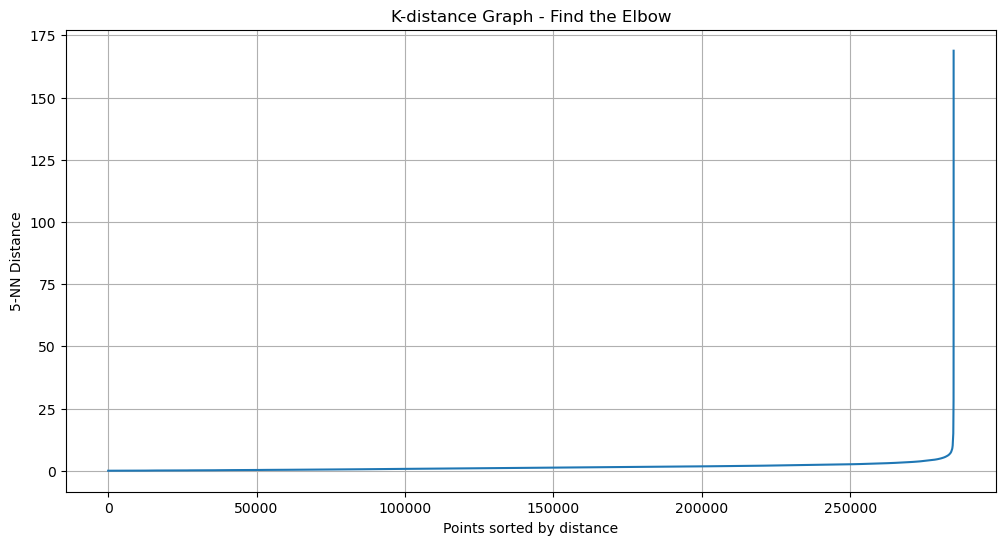

In [12]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(distances)
plt.ylabel('5-NN Distance')
plt.xlabel('Points sorted by distance')
plt.title('K-distance Graph - Find the Elbow')
plt.grid()
plt.show()



In [13]:
# Train DBSCAN

# Choose eps from the elbow (let's try 0.5)
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

In [14]:
print(f"Unique clusters: {set(clusters)}")
print(f"Noise points: {list(clusters).count(-1)}")

Unique clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70)

In [15]:
df['DBSCAN_Cluster'] = clusters

In [16]:
# How many clusters and noise points?
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

In [17]:
n_clusters

3202

In [18]:
n_noise

200552

In [19]:
df['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
-1       200552
 1691      1562
 1672      1195
 1693       946
 1732       860
          ...  
 3154         3
 1637         3
 3155         3
 3199         3
 1415         3
Name: count, Length: 3203, dtype: int64

In [20]:
df.shape

(284807, 32)

In [21]:

# Key insight - compare actual fraud with DBSCAN noise
print("\n=== FRAUD DETECTION RESULTS ===")
actual_fraud = df[df['Class'] == 1]
detected_noise  = df[df['DBSCAN_Cluster'] == -1]
actual_fraud



=== FRAUD DETECTION RESULTS ===


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,DBSCAN_Cluster
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1,-1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1,-1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1,-1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1,-1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1,-1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1,-1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1,-1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1,-1


In [22]:
detected_noise 


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,DBSCAN_Cluster
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,-1
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,-1
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,-1
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,-1
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284799,172783.0,-1.775135,-0.004235,1.189786,0.331096,1.196063,5.519980,-1.518185,2.080825,1.159498,...,0.654850,-0.348929,0.745323,0.704545,-0.127579,0.454379,0.130308,79.99,0,-1
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,-1
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,-1
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,-1


In [23]:
print(f"Total actual fraud: {len(actual_fraud)}")
print(f"Total detected noise: {len(detected_noise)}")
print(f"Overlap (fraud caught as noise): {len(actual_fraud[actual_fraud['DBSCAN_Cluster'] == -1])}")


Total actual fraud: 492
Total detected noise: 200552
Overlap (fraud caught as noise): 483


In [24]:
# Fraud rate in noise points
fraud_in_noise = detected_noise['Class'].sum()
print(f"Fraud rate in noise points: {fraud_in_noise / len(detected_noise) * 100:.2f}%")



Fraud rate in noise points: 0.24%


In [25]:
# Fraud rate in normal transactions
fraud_in_normal = df[df['DBSCAN_Cluster'] != -1]['Class'].sum()
print(f"Fraud rate in clusters: {fraud_in_normal / len(df[df['DBSCAN_Cluster'] != -1]) * 100:.2f}%")

Fraud rate in clusters: 0.01%


In [26]:
# Find best eps
print("Testing different eps values:\n")
for eps in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    clusters = dbscan.fit_predict(X_scaled)
    n_noise = list(clusters).count(-1)
    fraud_in_noise = df.loc[df['DBSCAN_Cluster'] == -1, 'Class'].sum()
    
    print(f"eps={eps}: {n_noise} noise points, fraud rate in noise: {fraud_in_noise/max(n_noise,1)*100:.2f}%")

Testing different eps values:

eps=0.3: 226880 noise points, fraud rate in noise: 0.21%
eps=0.4: 213284 noise points, fraud rate in noise: 0.23%
eps=0.5: 200552 noise points, fraud rate in noise: 0.24%
eps=0.6: 187907 noise points, fraud rate in noise: 0.26%
eps=0.7: 177901 noise points, fraud rate in noise: 0.27%
eps=0.8: 167120 noise points, fraud rate in noise: 0.29%


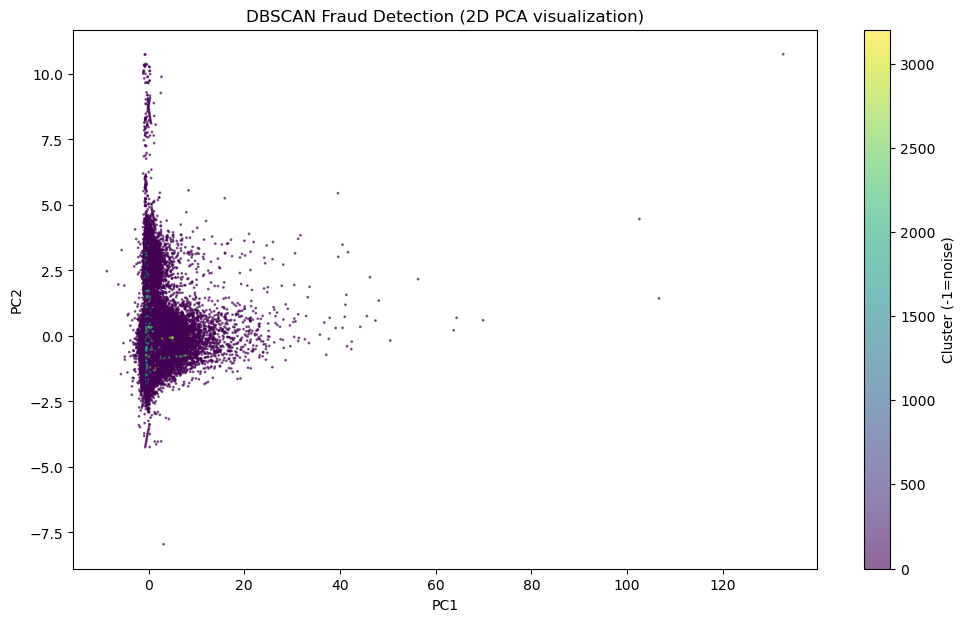

In [27]:
# Since data is 30D, project to 2D for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

# Train DBSCAN on original data, visualize in 2D
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(12, 7))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap='viridis', s=1, alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN Fraud Detection (2D PCA visualization)')
plt.colorbar(scatter, label='Cluster (-1=noise)')
plt.show()

In [28]:
print("=== BUSINESS INSIGHTS ===\n")

suspicious = df[df['DBSCAN_Cluster'] == -1]
total_fraud = df[df['Class'] == 1]

print(f"Total suspicious transactions flagged: {len(suspicious)}")
print(f"Actual fraud in suspicious: {suspicious['Class'].sum()}")

detection_rate = (suspicious['Class'].sum() / len(total_fraud)) * 100
false_positive_rate = ((len(suspicious) - suspicious['Class'].sum()) / len(suspicious)) * 100

print(f"Detection rate: {detection_rate:.2f}%")
print(f"False positive rate: {false_positive_rate:.2f}%")

print(f"\n✅ If we review {len(suspicious)} transactions ({len(suspicious)/len(df)*100:.2f}% of all),")
print(f"   we catch {suspicious['Class'].sum()} frauds (out of {len(total_fraud)} total)")

=== BUSINESS INSIGHTS ===

Total suspicious transactions flagged: 200552
Actual fraud in suspicious: 483
Detection rate: 98.17%
False positive rate: 99.76%

✅ If we review 200552 transactions (70.42% of all),
   we catch 483 frauds (out of 492 total)
